# Hyperparameter Tuning Analysis

Analysis of Bayesian Optimization hyperparameter tuning results.
Each combination of `kappa` and `kernel_variance` was tested 5 times (seeds 0-4) with 50 iterations per run.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../reports/hyperparameter_tuning_results.csv")
print(f"Total runs: {len(df)}")
print(f"Kappa values: {sorted(df['kappa'].unique())}")
print(f"Kernel variance values: {sorted(df['kernel_variance'].unique())}")
print(f"Seeds per combination: {len(df['seed'].unique())}")
df.head(10)

Total runs: 50
Kappa values: [np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5)]
Kernel variance values: [np.float64(1.0), np.float64(2.0)]
Seeds per combination: 5


,kappa,kernel_variance,seed,best_temperature
0,0.5,1.0,0,37.7
1,0.5,1.0,1,37.3
2,0.5,1.0,2,29.0
3,0.5,1.0,3,29.0
4,0.5,1.0,4,39.5
5,0.5,2.0,0,29.0
6,0.5,2.0,1,32.7
7,0.5,2.0,2,28.9
8,0.5,2.0,3,32.6
9,0.5,2.0,4,37.4


## Summary Table

Average, standard deviation, min and max of `best_temperature` across 5 seeds for each parameter combination.

In [4]:
summary = (
    df.groupby(["kappa", "kernel_variance"])["best_temperature"]
    .agg(["mean", "std", "min", "max"])
    .round(2)
    .sort_values("mean", ascending=False)
    .reset_index()
)
summary.columns = ["kappa", "kernel_variance", "avg_temp", "std_temp", "min_temp", "max_temp"]
summary.style.background_gradient(subset=["avg_temp"], cmap="YlOrRd")

,kappa,kernel_variance,avg_temp,std_temp,min_temp,max_temp
0,2.000000,1.000000,34.560000,2.190000,31.700000,37.700000
1,0.500000,1.000000,34.500000,5.090000,29.000000,39.500000
2,2.500000,1.000000,33.740000,2.010000,31.400000,36.400000
3,1.000000,2.000000,33.640000,2.540000,30.300000,36.300000
4,1.000000,1.000000,33.460000,4.060000,28.400000,39.300000
5,2.500000,2.000000,33.080000,2.120000,30.500000,36.400000
6,1.500000,1.000000,32.400000,2.810000,30.300000,37.100000
7,2.000000,2.000000,32.140000,4.150000,28.200000,37.300000
8,0.500000,2.000000,32.120000,3.480000,28.900000,37.400000
9,1.500000,2.000000,31.640000,0.920000,30.800000,33.200000


## Bar Chart: Average Best Temperature per Combination

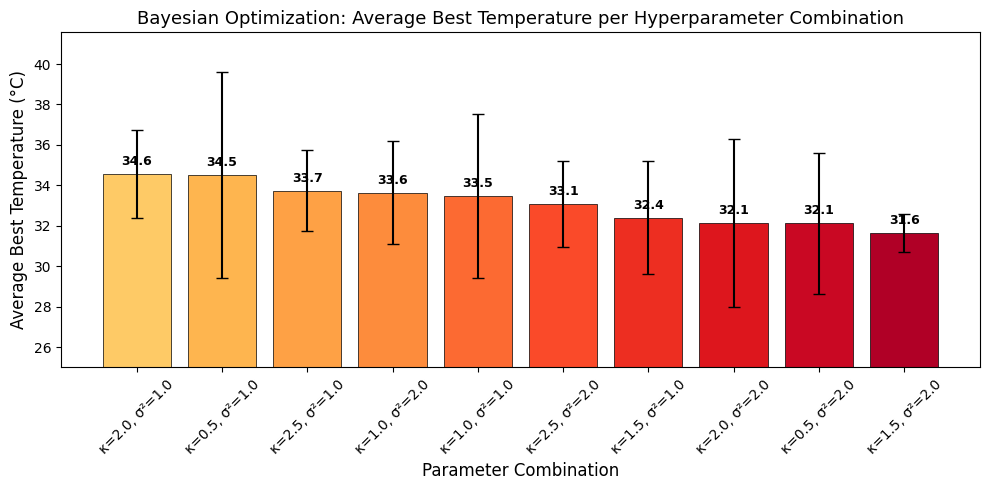

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

labels = [f"κ={row.kappa}, σ²={row.kernel_variance}" for _, row in summary.iterrows()]
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(summary)))

bars = ax.bar(labels, summary["avg_temp"], yerr=summary["std_temp"],
              capsize=4, color=colors, edgecolor="black", linewidth=0.5)

ax.set_ylabel("Average Best Temperature (°C)", fontsize=12)
ax.set_xlabel("Parameter Combination", fontsize=12)
ax.set_title("Bayesian Optimization: Average Best Temperature per Hyperparameter Combination", fontsize=13)
ax.tick_params(axis="x", rotation=45)

for bar, val in zip(bars, summary["avg_temp"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_ylim(bottom=25)
plt.tight_layout()
plt.show()

## Heatmap: Average Best Temperature

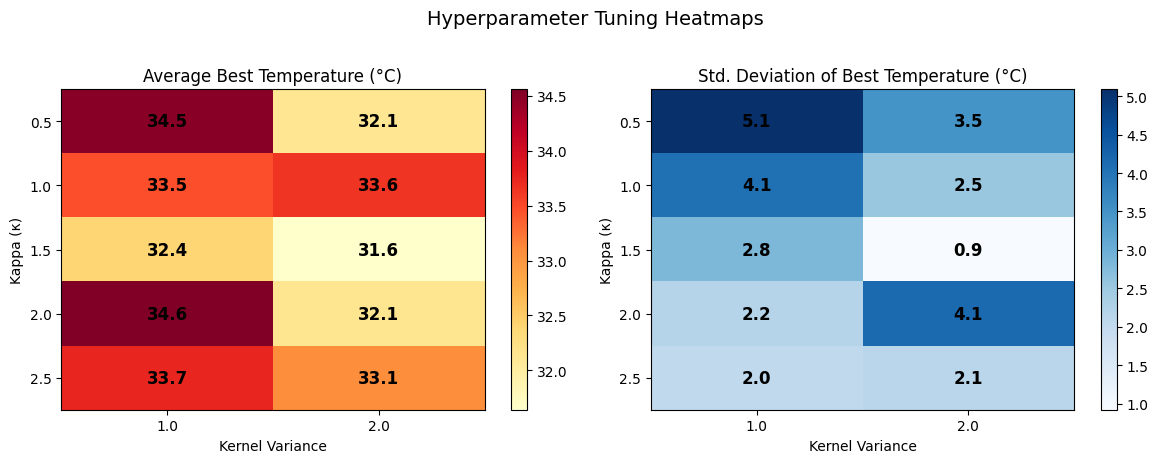

In [6]:
pivot_mean = df.groupby(["kappa", "kernel_variance"])["best_temperature"].mean().unstack()
pivot_std = df.groupby(["kappa", "kernel_variance"])["best_temperature"].std().unstack()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

im1 = axes[0].imshow(pivot_mean.values, cmap="YlOrRd", aspect="auto")
axes[0].set_xticks(range(len(pivot_mean.columns)))
axes[0].set_xticklabels(pivot_mean.columns)
axes[0].set_yticks(range(len(pivot_mean.index)))
axes[0].set_yticklabels(pivot_mean.index)
axes[0].set_xlabel("Kernel Variance")
axes[0].set_ylabel("Kappa (κ)")
axes[0].set_title("Average Best Temperature (°C)")
for i in range(len(pivot_mean.index)):
    for j in range(len(pivot_mean.columns)):
        axes[0].text(j, i, f"{pivot_mean.values[i, j]:.1f}",
                     ha="center", va="center", fontsize=12, fontweight="bold")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(pivot_std.values, cmap="Blues", aspect="auto")
axes[1].set_xticks(range(len(pivot_std.columns)))
axes[1].set_xticklabels(pivot_std.columns)
axes[1].set_yticks(range(len(pivot_std.index)))
axes[1].set_yticklabels(pivot_std.index)
axes[1].set_xlabel("Kernel Variance")
axes[1].set_ylabel("Kappa (κ)")
axes[1].set_title("Std. Deviation of Best Temperature (°C)")
for i in range(len(pivot_std.index)):
    for j in range(len(pivot_std.columns)):
        axes[1].text(j, i, f"{pivot_std.values[i, j]:.1f}",
                     ha="center", va="center", fontsize=12, fontweight="bold")
plt.colorbar(im2, ax=axes[1])

plt.suptitle("Hyperparameter Tuning Heatmaps", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Box Plot: Spread of Results per Combination

/var/folders/tc/kcvxq0px1svf293wbm1j742w0000gn/T/ipykernel_75978/1110457971.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(combo_data, labels=combo_labels, patch_artist=True)


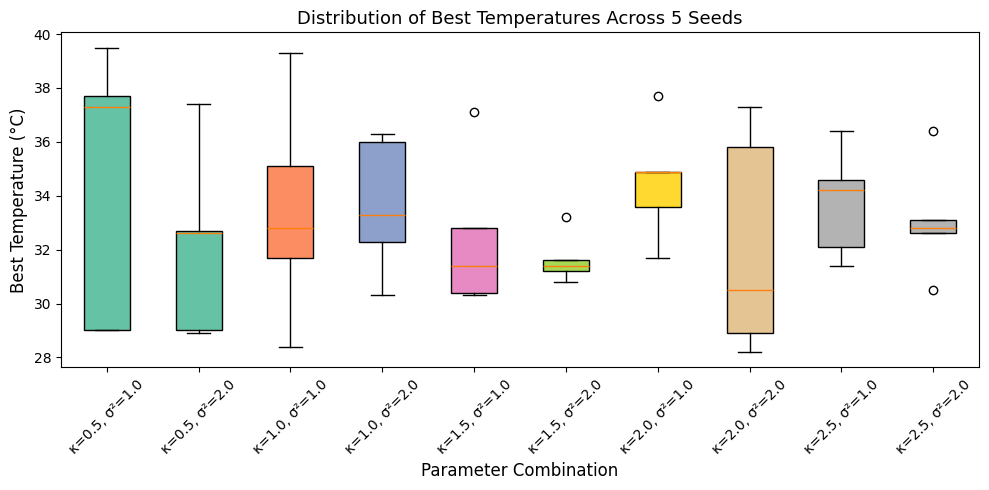

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

combos = df.groupby(["kappa", "kernel_variance"])
combo_labels = [f"κ={k}, σ²={v}" for (k, v) in combos.groups.keys()]
combo_data = [group["best_temperature"].values for _, group in combos]

bp = ax.boxplot(combo_data, labels=combo_labels, patch_artist=True)

colors = plt.cm.Set2(np.linspace(0, 1, len(combo_data)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

ax.set_ylabel("Best Temperature (°C)", fontsize=12)
ax.set_xlabel("Parameter Combination", fontsize=12)
ax.set_title("Distribution of Best Temperatures Across 5 Seeds", fontsize=13)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Effect of Each Parameter Individually

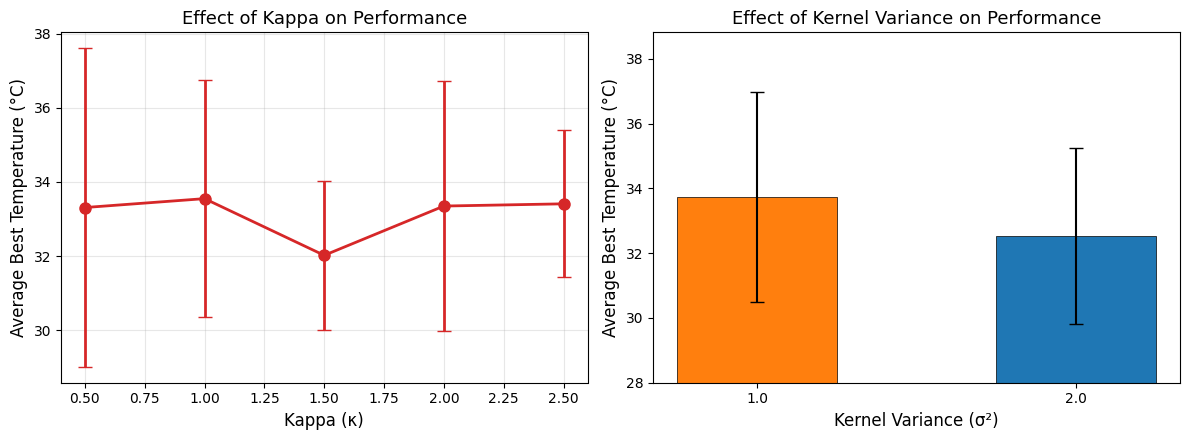

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

kappa_avg = df.groupby("kappa")["best_temperature"].agg(["mean", "std"]).reset_index()
axes[0].errorbar(kappa_avg["kappa"], kappa_avg["mean"], yerr=kappa_avg["std"],
                 marker="o", capsize=5, linewidth=2, markersize=8, color="#d62728")
axes[0].set_xlabel("Kappa (κ)", fontsize=12)
axes[0].set_ylabel("Average Best Temperature (°C)", fontsize=12)
axes[0].set_title("Effect of Kappa on Performance", fontsize=13)
axes[0].grid(True, alpha=0.3)

var_avg = df.groupby("kernel_variance")["best_temperature"].agg(["mean", "std"]).reset_index()
axes[1].bar(var_avg["kernel_variance"].astype(str), var_avg["mean"], yerr=var_avg["std"],
            capsize=5, color=["#ff7f0e", "#1f77b4"], edgecolor="black", linewidth=0.5, width=0.5)
axes[1].set_xlabel("Kernel Variance (σ²)", fontsize=12)
axes[1].set_ylabel("Average Best Temperature (°C)", fontsize=12)
axes[1].set_title("Effect of Kernel Variance on Performance", fontsize=13)
axes[1].set_ylim(bottom=28)

plt.tight_layout()
plt.show()

## Conclusion

In [9]:
best = summary.iloc[0]
print("Best hyperparameter combination:")
print(f"  Kappa (κ):          {best['kappa']}")
print(f"  Kernel Variance:    {best['kernel_variance']}")
print(f"  Avg Best Temp:      {best['avg_temp']:.2f} °C")
print(f"  Std Dev:            {best['std_temp']:.2f} °C")
print(f"  Best Single Run:    {best['max_temp']:.1f} °C")
print(f"  Worst Single Run:   {best['min_temp']:.1f} °C")

Best hyperparameter combination:
  Kappa (κ):          2.0
  Kernel Variance:    1.0
  Avg Best Temp:      34.56 °C
  Std Dev:            2.19 °C
  Best Single Run:    37.7 °C
  Worst Single Run:   31.7 °C
